# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import pandas as pd
from scapy.all import raw, PcapReader, Ether

from sklearn.model_selection import train_test_split

In [2]:
raw_x_path      = "../data/tow-ids-dataset/raw/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
raw_y_path      = "../data/tow-ids-dataset/raw/y_train.csv"
number_of_bytes = 58

In [3]:
labels = pd.read_csv(raw_y_path, header=None, names=["index", "class", "label"])
labels['label'] = labels['label'].map({
    'Normal': 'Normal',
    'C_D': 'CAN DoS',
    'P_I': 'PTP Sync',
    'M_F': 'Switch MAC Flooding',
    'F_I': 'Frame Injection',
    'C_R': 'CAN Replay',
})

In [4]:
def detect_protocol_scapy(pkt):
        """Detect protocol using Scapy's layer inspection."""
        eth_type = pkt[Ether].type

        if eth_type in [2054, 35061, 8938]:
            return 'L2'

        if eth_type in [2048, 34525]:
            return 'IP_UDP'
        
        if eth_type in [33024, 8944]:
            return 'AVTP'
        
        if eth_type in [35063]:
            return 'PTP'
        
        return '-1'

In [5]:
def plot_img_loss(img_loss, min=None, max=None, targets=[]):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i - 0.5, color='red', linewidth=1.5, alpha=0.1)  # top edge
            plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title("Mean Image Loss Map")
    plt.tight_layout()
    plt.show()
    plt.close()

In [6]:
def load(protocol_filter='AVTP'):
        """Load TOW-IDS dataset"""

        raw_x_path      = "../data/tow-ids-dataset/raw/Automotive_Ethernet_with_Attack_original_10_17_19_50_training.pcap"
        raw_y_path      = "../data/tow-ids-dataset/raw/y_train.csv"
        number_of_bytes = 58

        labels = pd.read_csv(raw_y_path, header=None, names=["pkt_idx", "class", "label"])
        labels['label'] = labels['label'].map({
            'Normal': 'Normal',
            'C_D': 'CAN DoS',
            'P_I': 'PTP Sync',
            'M_F': 'Switch MAC Flooding',
            'F_I': 'Frame Injection',
            'C_R': 'CAN Replay',
        })

        n = len(labels)
        values      = np.empty((n, number_of_bytes), dtype=np.float32)
        timestamps  = np.empty(n, dtype=object)
        protocols   = np.empty(n, dtype=object)

        with PcapReader(raw_x_path) as pcap_reader:
            for i, pkt in tqdm(enumerate(pcap_reader), total=n):
                protocol = detect_protocol_scapy(pkt)
                if (protocol_filter and (
                    (type(protocol_filter) == list and protocol not in protocol_filter) or 
                    (type(protocol_filter) != list and protocol != protocol_filter)
                    )):
                    continue

                b = raw(pkt)
                m = min(len(b), number_of_bytes)
                arr = np.frombuffer(b, dtype=np.uint8, count=m)
                if len(b) < number_of_bytes:
                    arr = np.pad(arr, (0, number_of_bytes - len(b)), 'constant')
                
                protocols[i]    = protocol
                timestamps[i]   = pkt.time
                values[i]       = arr

        values /= 255.0

        labels['timestamp'] = timestamps
        labels['protocol'] = protocols
        labels.dropna(inplace=True)

        valid_idx = labels.index
        values = values[valid_idx]

        return values, labels

In [7]:
import pickle
import torch


def save(X: np.ndarray, y: pd.DataFrame, path='sequence.pt'):
    torch.save({'X': X, 'y': y}, path, pickle_protocol=pickle.HIGHEST_PROTOCOL)

def load_sequence(path='sequence.pt'):
    cache = torch.load(path, weights_only=False)
    X, y = cache['X'], cache['y']
    return X, y

In [8]:
data, labels = load(protocol_filter='AVTP')

 21%|██        | 253042/1203737 [00:45<02:50, 5586.21it/s]


KeyboardInterrupt: 

In [38]:
byte_start  = 50
byte_end    = 58
save(data[:, byte_start:byte_end], labels, path=f'sequence_b_{byte_start}:{byte_end}.pt')

In [39]:
import logging
import yaml

import sys
sys.path.append("../")

from data_pre_processing.factory import DataPreProcessingFactory
from modeling.inference.factory import ModelingInferenceFactory
from modeling.structure.factory import ModelingStructureFactory
from modeling.training.factory import ModelingTrainingFactory
from tracker.base_tracker import BaseTracker
from utils.get_device import get_device
from utils.seed_all import seed_all


DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [40]:
def plot_line(y_pred, y_true=None, name="True vs Predicted values"):
    plt.figure(figsize=(12, 6))

    # Plot true values
    if y_true is not None:
        x_true = np.arange(len(y_true))
        plt.plot(x_true, y_true, marker='x', label="True values", color="red")

        # Align predictions to the *end* of true series
        start_idx = len(y_true) - len(y_pred)
        x_pred = np.arange(start_idx, start_idx + len(y_pred))
    else:
        # If no y_true, just start from 0
        x_pred = np.arange(len(y_pred))
    plt.plot(x_pred, y_pred, marker='o', label="Prediction values", color="blue")

    # Labels, title, legend
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
def plot_multi_channel(y_preds, y_trues=None, n_channels=10):
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]  # handle single channel case

    for i in range(n_channels):
        ax = axes[i]
        y_pred = y_preds[i]
        y_true = None if y_trues is None else y_trues[i]

        if y_true is not None:
            x_true = np.arange(len(y_true))
            ax.plot(x_true, y_true, marker='x', label="True", color="red")
            start_idx = len(y_true) - len(y_pred)
            x_pred = np.arange(start_idx, start_idx + len(y_pred))
        else:
            x_pred = np.arange(len(y_pred))

        ax.plot(x_pred, y_pred, marker='o', label="Pred", color="blue")
        ax.set_title(f"Channel {i+1}")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Instance

In [42]:
path = '../configs/tcn_pred.yaml'
with open(path, "r") as f:
    config = yaml.safe_load(f)

In [43]:
config['run_id'] = 'sequence_model'    
config['phase'] = 'train' # persist phase
run_id = config['run_id']

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

pre_processing = DataPreProcessingFactory().get(config, logger)

device = get_device()

model = ModelingStructureFactory().get(config, logger, device)
model.compile()

tracker = BaseTracker()

trainer = ModelingTrainingFactory().get(config, logger, device, tracker)

model_inference = ModelingInferenceFactory().get(config, logger, device)

/Users/mauriciosightman/Documents/Work/master/RABID/.venv/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


# Training

In [47]:
byte_start  = 50
byte_end    = 58
values, labels = load_sequence(path=f'sequence_b_{byte_start}:{byte_end}.pt')

In [49]:
data.shape

(287087, 50)

In [48]:
values.shape

(287087, 0)

In [44]:
subset = 0.1
(X_view, starts), y = pre_processing.process(values, labels)
starts = np.random.choice(starts, size=int(subset*len(starts)), replace=False)
y = y.iloc[starts].reset_index(drop=True)
X = X_view[starts]
del X_view, starts

IndexError: index 286960 is out of bounds for axis 0 with size 286960

In [16]:
train_val_idx, test_idx = train_test_split(np.arange(X.shape[0]), train_size=0.8, random_state=DEFAULT_SEED, shuffle=True)

In [17]:
# 4. Execute training
logger.debug("Starting training...")
train_loss, train_val_loss = trainer.train(model, X[train_val_idx], y.iloc[train_val_idx])
logger.info(f"Training completed. Train loss: {train_loss}, Training validation loss: {train_val_loss}")

2025-09-18 14:28:30,405 | INFO | Train size: 33668, Validation size: 8418
2025-09-18 14:28:30,412 | INFO | Train labels: 
label
Normal    33668
Name: count, dtype: int64
2025-09-18 14:28:30,415 | INFO | Validation labels: 
label
Normal    8418
Name: count, dtype: int64
2025-09-18 14:28:30,463 | INFO | Running for 10 epochs
2025-09-18 14:28:30,464 | INFO | -------------------- Training started -------------------
2025-09-18 14:28:32,077 | INFO | Epoch: 0 	[0/2105 (0%)]	Loss: 1.139261
2025-09-18 14:28:55,779 | INFO | Epoch: 0 	[0/527 (0%)]	Validation loss: 0.055331
2025-09-18 14:28:56,050 | INFO | Epoch: 0 	[528/527 (6%)]	Validation loss: 0.065320
2025-09-18 14:28:56,059 | INFO | Epoch: 0 	[544/527 (6%)]	Validation loss: 0.054428
2025-09-18 14:28:56,066 | INFO | Epoch: 0 	[560/527 (7%)]	Validation loss: 0.067507
2025-09-18 14:28:56,072 | INFO | Epoch: 0 	[576/527 (7%)]	Validation loss: 0.059721
2025-09-18 14:28:56,078 | INFO | Epoch: 0 	[592/527 (7%)]	Validation loss: 0.056147
2025-09-18

In [18]:
X_test = X[test_idx]
y_test = y.iloc[test_idx].reset_index()

In [19]:
# 5. Validate
y_true, (y_pred, y_scores), val_loss = model_inference.inference(model, X[test_idx], y.iloc[test_idx])
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)
y_true['scores'] = y_scores.mean(axis=(1, 2))
y_true_benign = y_true[y_true["label"] == 'Normal']

2025-09-18 14:33:08,849 | INFO | Testing labels: 
label
Normal                 10414
CAN DoS                 3083
Switch MAC Flooding     1686
CAN Replay              1601
Name: count, dtype: int64
2025-09-18 14:33:09,541 | INFO | Test loss: 0.067761 	[0/16784 (0%)]


# Analyzing results

In [20]:
_, w, n = y_pred.shape

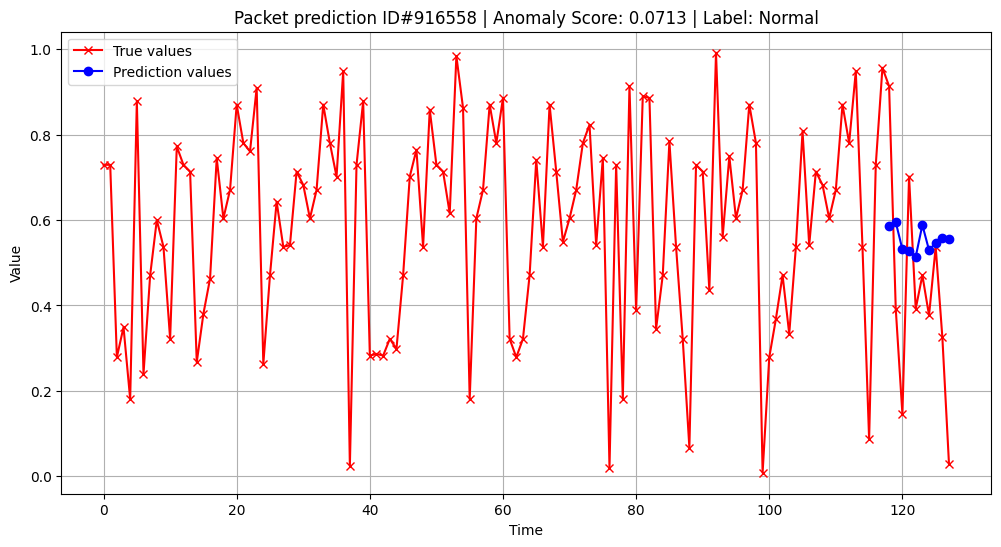

In [27]:
channel = 0
idx = y_true.index[0]
start_idx = y_true['start_idx'].iloc[idx]
test_idx = y_test[y_test['start_idx'] == start_idx].index
plot_line(y_pred.reshape(-1, n, w)[idx][channel], 
          y_true=X_test[test_idx].reshape(-1, n, 128)[0][channel],
          name=f'Packet prediction ID#{start_idx} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f} | Label: {y_true['label'].iloc[idx]}')

In [28]:
values.shape

(839294, 1)

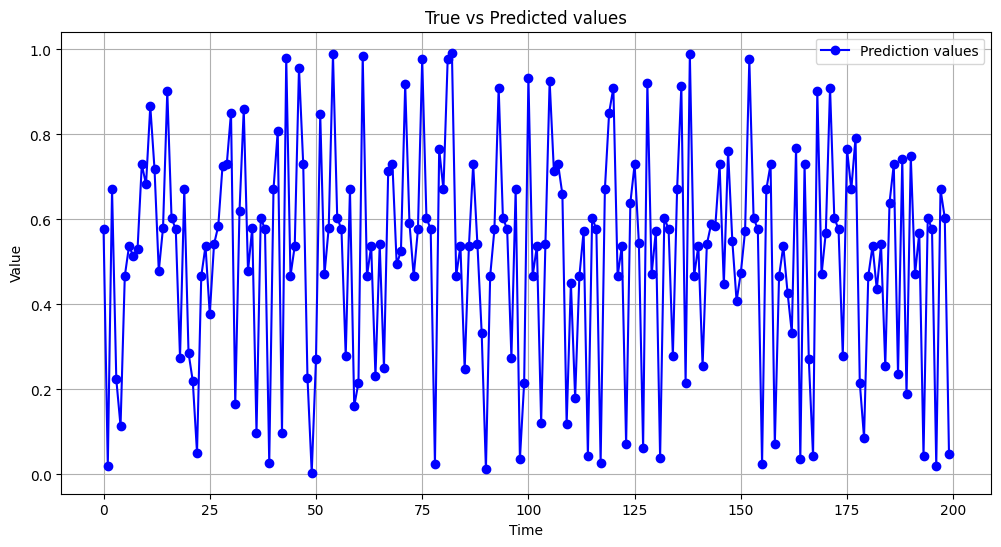

In [30]:
plot_line(values[:200])

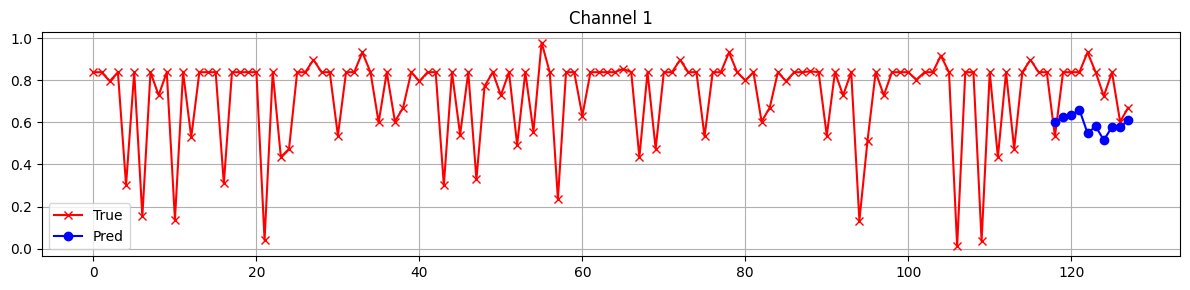

In [24]:
plot_multi_channel(y_pred.reshape(-1, n, w)[idx], X_test[test_idx].reshape(-1, n, 128)[0], n_channels=1)

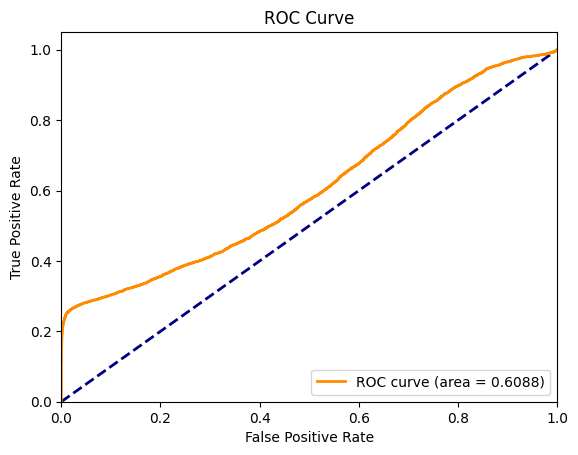

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [ ]:
# 53